<a href="https://colab.research.google.com/github/zhakhinaaaa/titanic-survival/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

USER = "zhakhinaaaa"
BASE = f"https://raw.githubusercontent.com/{USER}/titanic-survival/main/data/"

train = pd.read_csv(BASE + "train.csv")
test = pd.read_csv(BASE + "test.csv")

print("train:", train.shape, " test:", test.shape)
train.head()

train: (891, 12)  test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()
print("\nПропуски в train:\n", train.isnull().sum())
print("\nПропуски в test:\n", test.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Пропуски в train:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked       

In [5]:
sns.set_theme(style="whitegrid")
COLORS = {0: "#eb6834", 1: "#2a78d6"}   # оранжевый = погиб, синий = выжил
LABELS = {0: "Погиб", 1: "Выжил"}
BAR = "#2a78d6"

Выжило: 342 из 891 (38.4%)


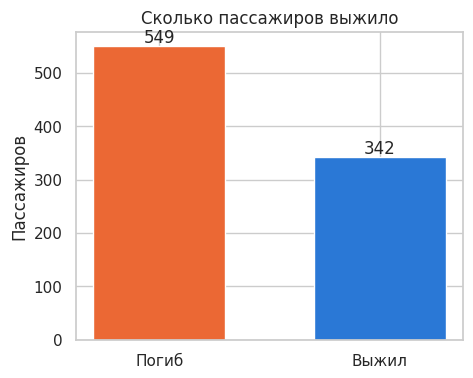

In [6]:
counts = train["Survived"].value_counts().sort_index()
print(f"Выжило: {counts[1]} из {len(train)} ({train['Survived'].mean():.1%})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([LABELS[0], LABELS[1]], counts.values, color=[COLORS[0], COLORS[1]], width=0.6)
ax.bar_label(ax.containers[0])
ax.set_title("Сколько пассажиров выжило"); ax.set_ylabel("Пассажиров")
plt.show()

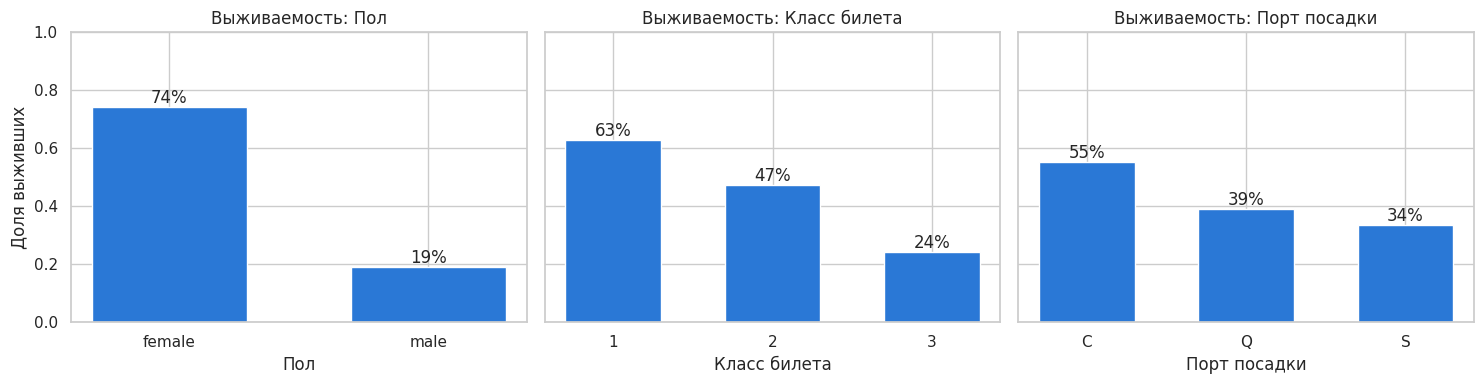

Sex     female  male
Pclass              
1         0.97  0.37
2         0.92  0.16
3         0.50  0.14


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col, title in zip(axes, ["Sex", "Pclass", "Embarked"],
                          ["Пол", "Класс билета", "Порт посадки"]):
    rate = train.groupby(col)["Survived"].mean()
    ax.bar(rate.index.astype(str), rate.values, color=BAR, width=0.6)
    ax.bar_label(ax.containers[0], labels=[f"{v:.0%}" for v in rate.values])
    ax.set_title(f"Выживаемость: {title}"); ax.set_xlabel(title); ax.set_ylim(0, 1)
axes[0].set_ylabel("Доля выживших")
plt.tight_layout(); plt.show()

# пол и класс вместе
print(pd.crosstab(train["Pclass"], train["Sex"],
                  values=train["Survived"], aggfunc="mean").round(2))

### Пол, класс и порт посадки
**Пол — главный фактор:** выжили ~74% женщин и только ~19% мужчин (принцип «женщины и дети первыми»). Выживаемость падает с классом: 63% в 1-м, 47% во 2-м, 24% в 3-м.
Из Шербура (C) выжили ~55%, из Саутгемптона (S) ~34%: в Шербуре садилось больше пассажиров 1-го класса. Поэтому порт влияет не сам по себе, а через класс.

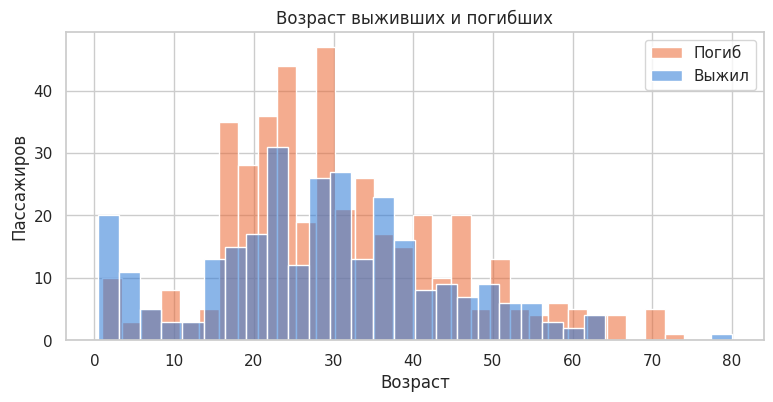

       mean  count
Age               
0-12   0.58     69
13-18  0.43     70
19-35  0.38    358
36-60  0.40    195
60+    0.23     22


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for s in [0, 1]:
    sns.histplot(train.loc[train["Survived"] == s, "Age"].dropna(), bins=30,
                 color=COLORS[s], alpha=0.55, label=LABELS[s], ax=ax)
ax.set_title("Возраст выживших и погибших")
ax.set_xlabel("Возраст"); ax.set_ylabel("Пассажиров"); ax.legend()
plt.show()

age_group = pd.cut(train["Age"], bins=[0, 12, 18, 35, 60, 80],
                   labels=["0-12", "13-18", "19-35", "36-60", "60+"])
print(train.groupby(age_group, observed=True)["Survived"].agg(["mean", "count"]).round(2))

### Возраст
У детей до 12 лет выживаемость заметно выше (~58%): их спасали в первую очередь. У пожилых пассажиров (60+) шансы самые низкие.
Основная масса пассажиров — 20–40 лет, и среди них погибших больше, чем выживших.

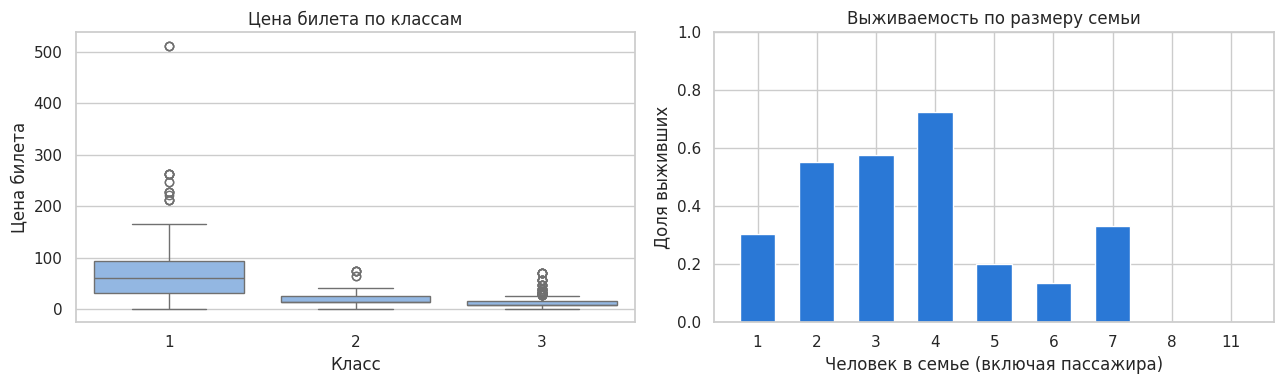

In [10]:
family = train["SibSp"] + train["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=train, x="Pclass", y="Fare", color="#86b6ef", ax=axes[0])
axes[0].set_title("Цена билета по классам")
axes[0].set_xlabel("Класс"); axes[0].set_ylabel("Цена билета")

rate = train.groupby(family)["Survived"].mean()
axes[1].bar(rate.index.astype(str), rate.values, color=BAR, width=0.6)
axes[1].set_title("Выживаемость по размеру семьи")
axes[1].set_xlabel("Человек в семье (включая пассажира)")
axes[1].set_ylabel("Доля выживших"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

### Цена билета и размер семьи
Билеты 1-го класса намного дороже (медиана ~60 против ~8 в 3-м классе), поэтому цена билета отражает социальный статус пассажира.
Одиночки выживали хуже (~30%), семьи из 2–4 человек лучше (55–72%), а большие семьи (5+) почти не выжили: им было сложнее держаться вместе.

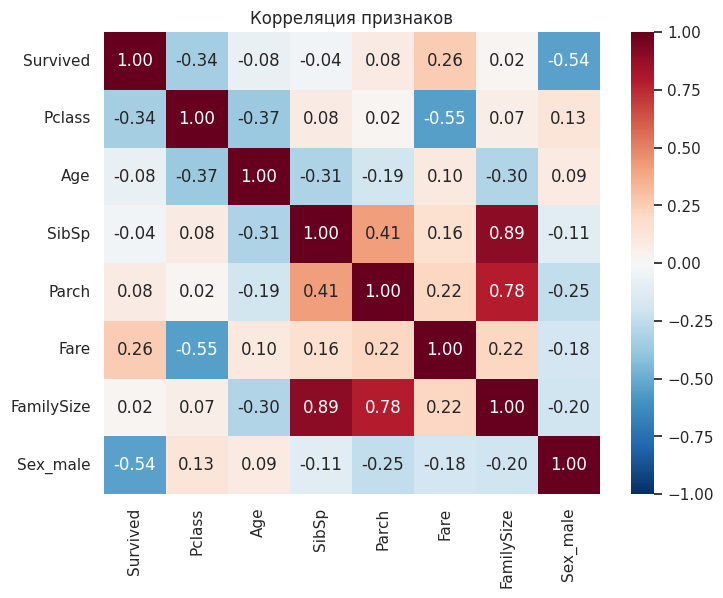

Sex_male     -0.543351
Pclass       -0.338481
Age          -0.077221
SibSp        -0.035322
FamilySize    0.016639
Parch         0.081629
Fare          0.257307
Survived      1.000000
Name: Survived, dtype: float64


In [11]:
num = train[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].copy()
num["FamilySize"] = family
num["Sex_male"] = (train["Sex"] == "male").astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Корреляция признаков"); plt.show()
print(num.corr()["Survived"].sort_values())

### Корреляции
Сильнее всего с выживанием связаны пол (Sex_male ≈ −0.54), класс (Pclass ≈ −0.34) и цена билета (Fare ≈ +0.26).
Age, SibSp и Parch по отдельности почти не коррелируют с выживанием, но полезны в комбинации (например, дети и размер семьи), поэтому оставим их для модели.

## Итоги анализа
1. Больше всего шансов было у женщин и детей из 1–2 класса.
2. Самые уязвимые — мужчины 3-го класса.
3. Для модели важнейшие признаки: пол, класс, возраст, цена билета, размер семьи.